In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import peak_selection as psel


# PNS


In [2]:
path = "trig_2298_chID_0.npz"
data = np.load(path)
X = data["X"]  
print(int(np.max(X)))

pulse_ds = psel.build_pulse_dataset(
    X,
    pre=40, post=216,
    use_pos="align",  # "align" "argmax"
    align_frac = 0.2,
    align_search_back = 400,
    ADCsat=16383,          # 16383
    amp_min=0,
    skip_flagged_records=False,
    drop_failed_align=True, # True

    store_baseline_interpolation=True   # usually False (big); enable for debugging and plotting
)


16383

=== Cutflow summary ===
Records total:            2298
Records drift-flagged:    508
Records skipped (drift):  0

Peaks detected:           131639
Removed: failed align:    0  (0.00%)
Removed: saturation:      1344  (1.02%)
Removed: amp_min:         0  (0.00%)
Removed: amp_max:         0  (0.00%)
Peaks kept after cuts:    131639  (100.00%)

Removed: edge window:     1387  (1.05%)
Removed: peak outside win:0  (0.00%)

Final pulses extracted:   128908  (97.93% of detected)



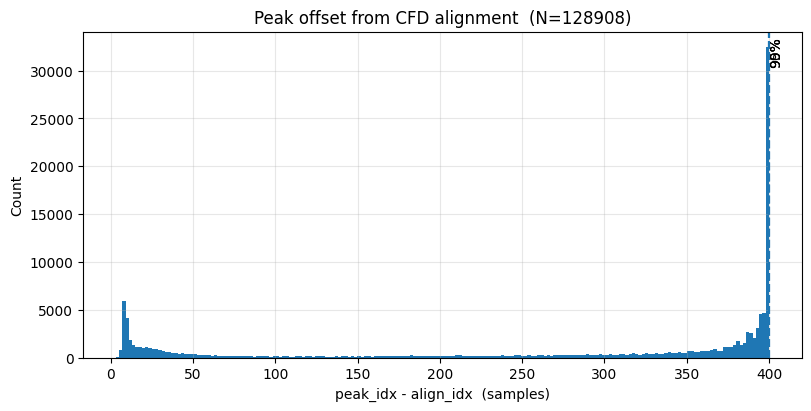

Peak offset statistics:
  min: 3.0
  max: 400.0
  mean: 272.3
  90th percentile: 400.0
  95th percentile: 400.0
  99th percentile: 400.0


In [3]:
delta = psel.analyze_peak_offset_from_align(pulse_ds)

In [17]:
post_rec, stats = psel.recommend_window_post_from_pulse_ds(
    pulse_ds,
    quantile=0.995,
    margin=12,
    ADCsat=None,
)

print("Recommended post:", post_rec)
print(stats)

Recommended post: 412
{'N': 128908, 'N_used': 128908, 'quantile': 0.995, 'q_value': 400.0, 'margin': 12, 'recommended_post': 412, 'min': 3.0, 'max': 400.0, 'mean': 272.2663992925187, 'std': 153.76846827583884, 'neg_frac': 0.0, 'p95': 400.0, 'p99': 400.0}


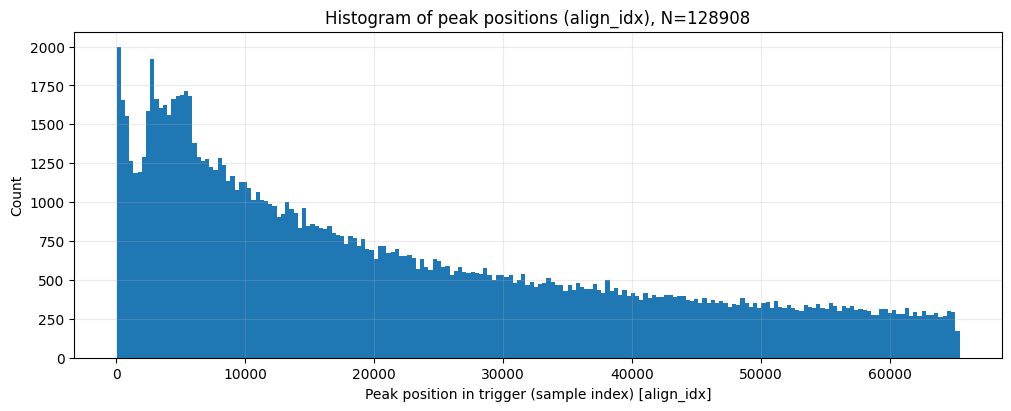

In [18]:
psel.plot_peak_position_histogram(
    pulse_ds,
    # use="argmax",
    use="align",
    bins=200
);

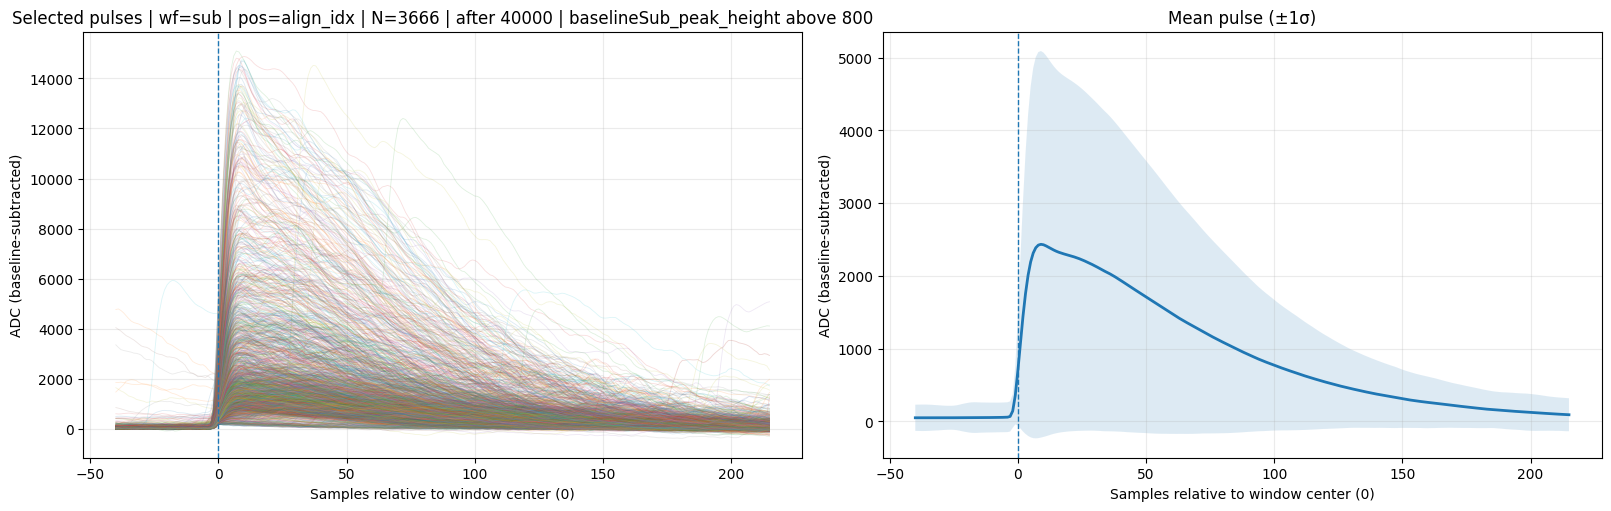

In [ ]:
wins, meta = psel.plot_pulses(
    pulse_ds,
    waveform="sub",
    use_pos="align",
    pos_side="after", pos_cut=40000,
    amp_side="above", amp_cut=800,
    ADCsat=None,
)

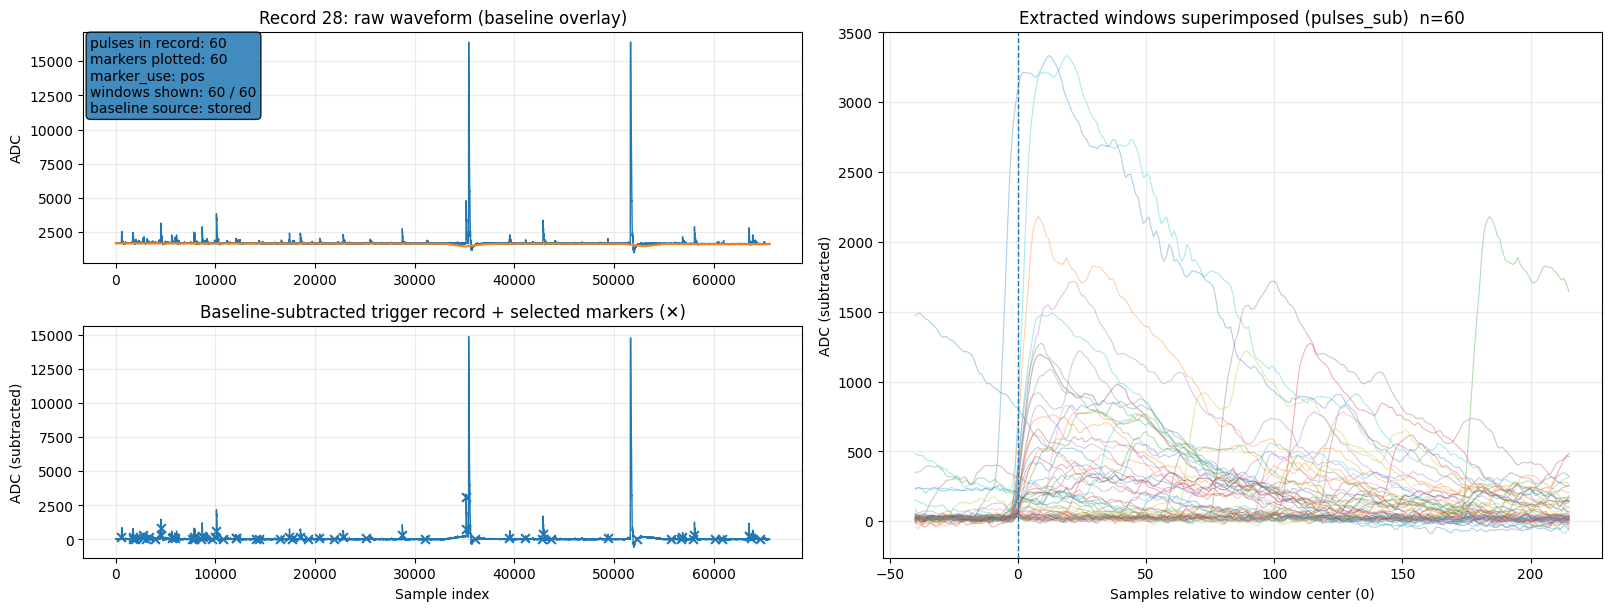

In [ ]:
W_rec, idx = psel.plot_record(
    X, pulse_ds,
    record_index=28,
)

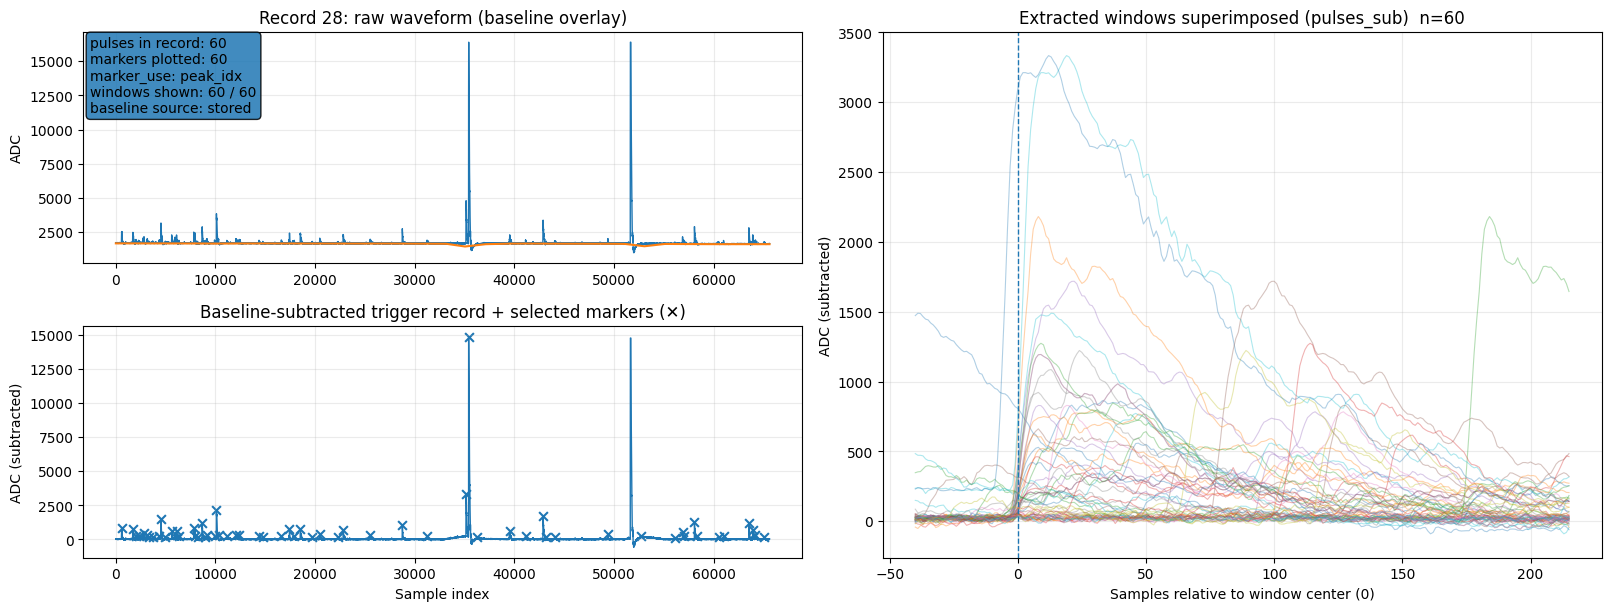

In [ ]:
W_rec, idx = psel.plot_record(
    X, pulse_ds,
    record_index=28,
    marker_use="peak_idx",
)

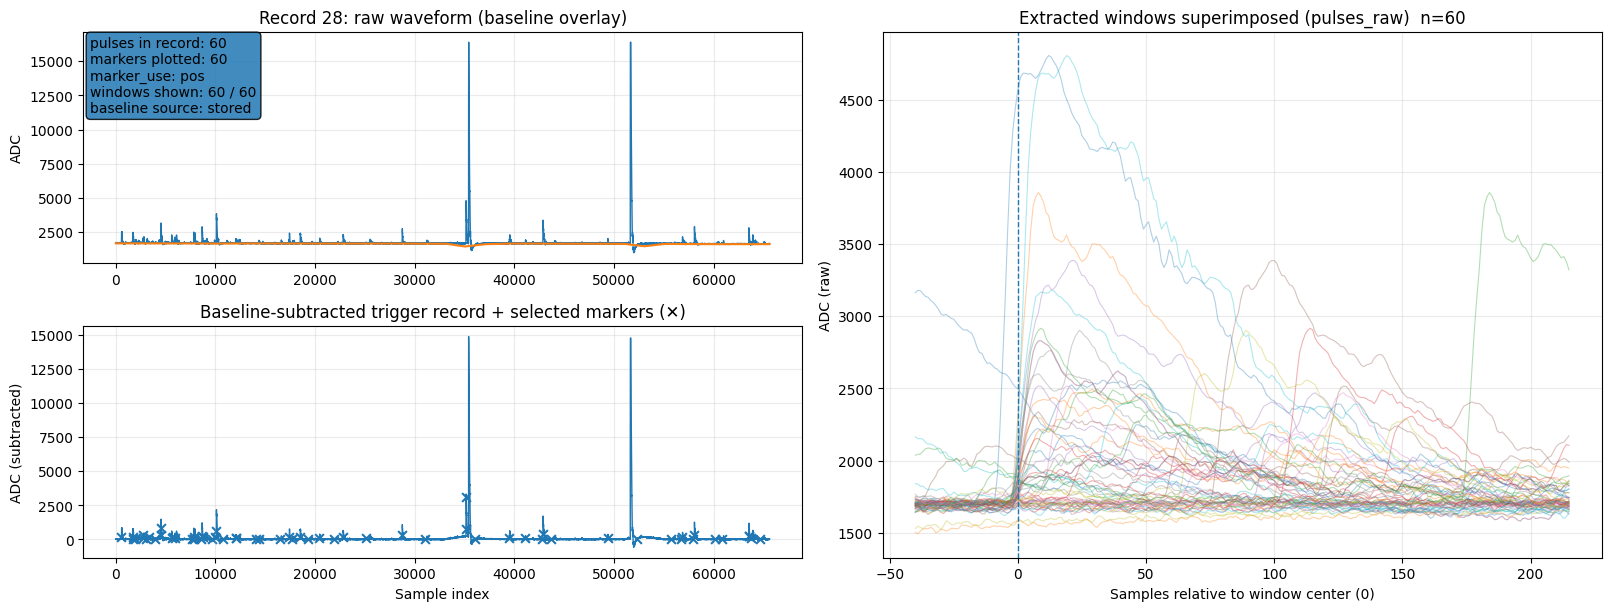

In [ ]:
W_rec, idx = psel.plot_record(
    X, pulse_ds,
    record_index=28,
    windows="raw",
    marker_use="pos",
    max_pulses_to_plot=300,
)

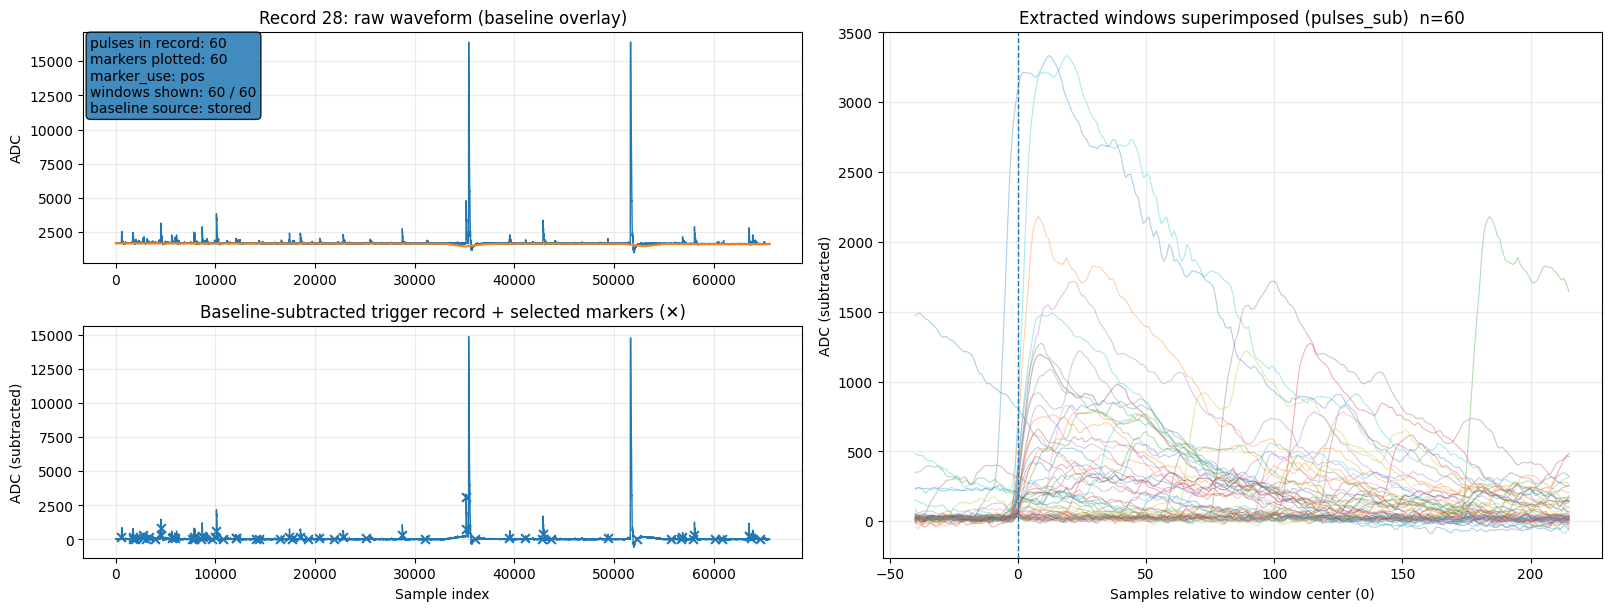

In [ ]:
W_rec, idx = psel.plot_record(
    X, pulse_ds,
    record_index=28,
    allow_baseline_fallback=False,
)

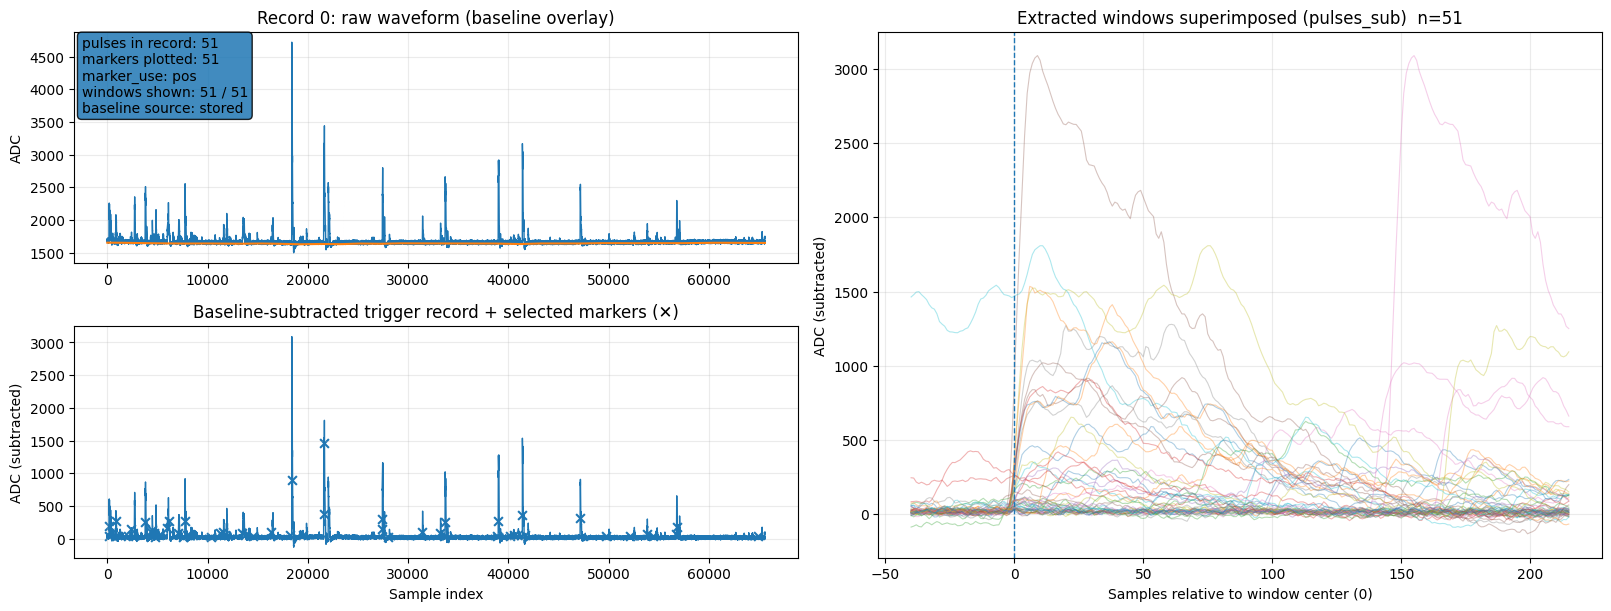

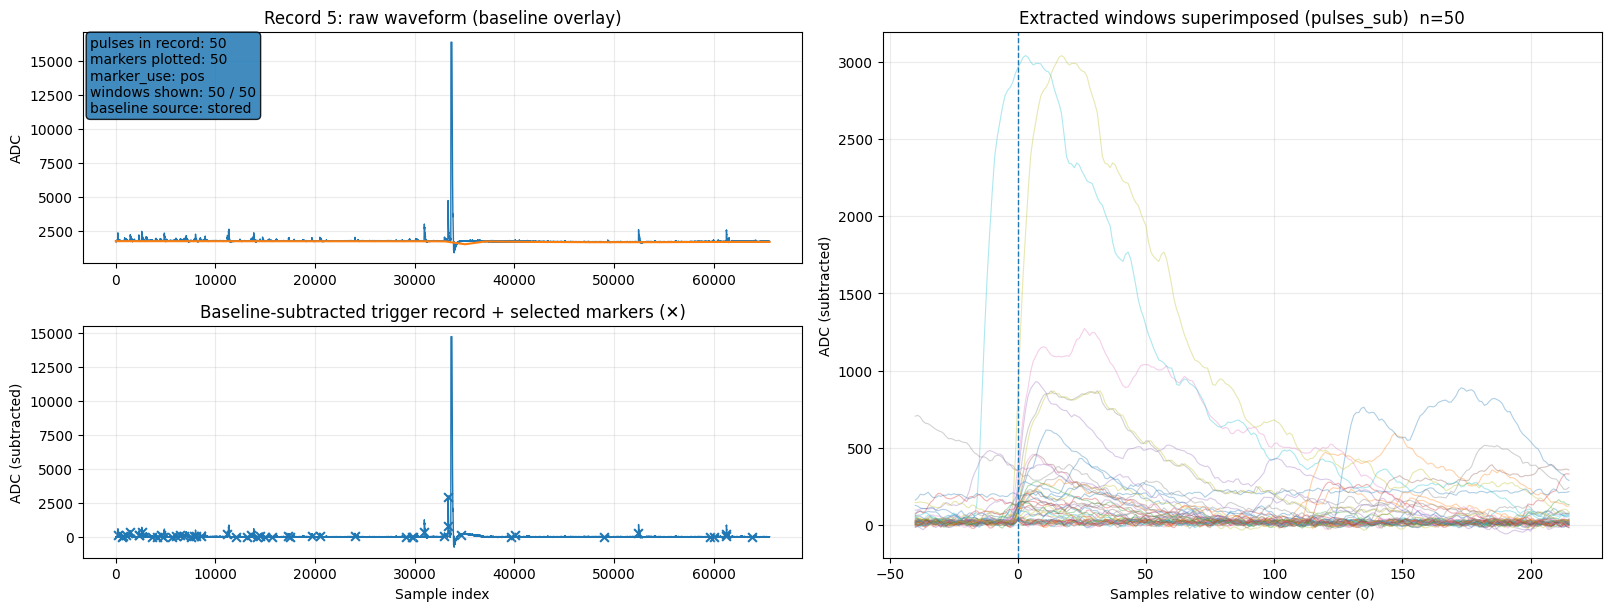

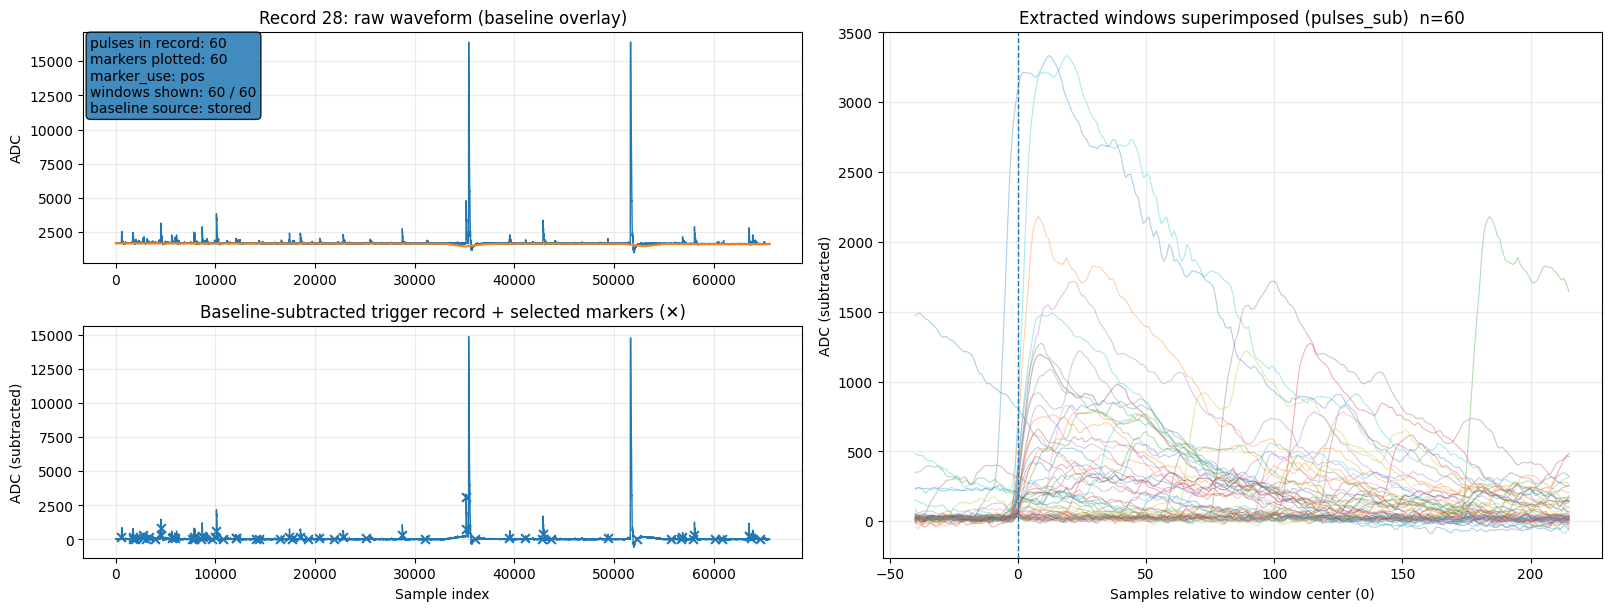

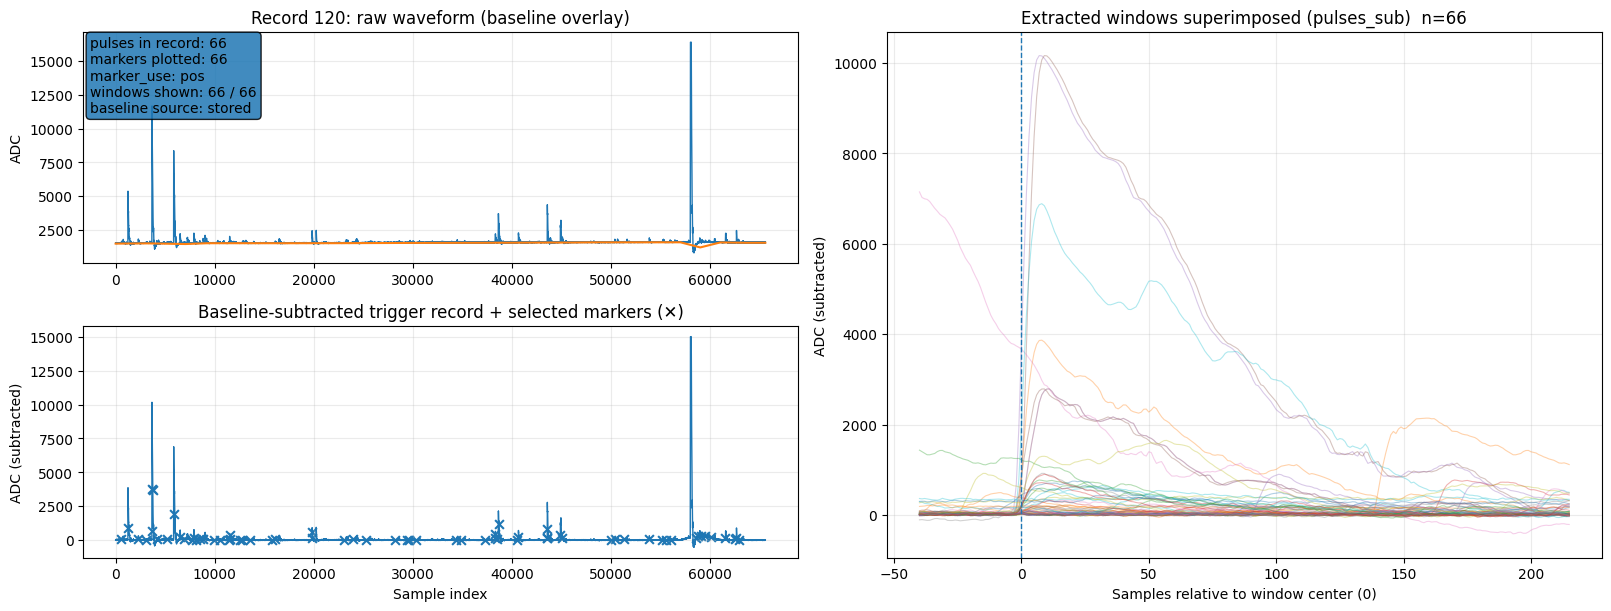

In [ ]:
for ri in [0, 5, 28, 120]:
    psel.plot_record(X, pulse_ds, record_index=ri, max_pulses_to_plot=200)